[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Evaluaciones/TrompoQuiz4.ipynb)

## El Trompo Simétrico Pesado con un Punto Fijo

### Descripción del Problema Físico

El problema se centra en analizar el movimiento de un cuerpo simétrico sometido a un campo gravitacional uniforme, con la restricción de que un punto sobre su eje de simetría permanece fijo en el espacio. Este es un modelo excelente para aproximar el comportamiento de sistemas físicos reales, desde un trompo de juguete hasta instrumentos de navegación giroscópicos complejos.

Para describir la configuración del trompo, el eje de simetría se define como el eje $z$ del sistema de coordenadas fijo al cuerpo. Dado que hay un punto estacionario, la posición del trompo queda completamente determinada por tres ángulos de Euler :

**$\theta$**: Mide la inclinación del eje $z$ respecto a la vertical espacial.

**$\phi$**: Mide el acimut del trompo alrededor de la vertical.

**$\psi$**: Es el ángulo de rotación del trompo sobre su propio eje $z$.

Las tasas de cambio de estos ángulos definen los movimientos característicos del sistema:

**$\dot{\psi}$**: Rotación o giro del trompo sobre su eje de simetría.

**$\dot{\phi}$**: Precesión (rotación del eje de la figura alrededor del eje vertical).

**$\dot{\theta}$**: Nutación (cabeceo del eje de la figura respecto a la vertical).

Además, se define $l$ como la distancia desde el punto fijo hasta el centro de gravedad (el cual se ubica sobre el eje de simetría).

---
### ¿Por qué utilizar el enfoque Lagrangiano?

Aunque las ecuaciones de Euler rigen la dinámica del cuerpo rígido, estas describen el cambio de las velocidades angulares ($\omega_1, \omega_2, \omega_3$) en el sistema de ejes principales. Sin embargo, experimentalmente lo que se observa son los cambios en los ángulos de Euler ($\dot{\psi}, \dot{\phi}, \dot{\theta}$). Debido a esto, el procedimiento Lagrangiano proporciona una descripción del movimiento mucho más útil y directa que las ecuaciones de Euler.

**Energía del Sistema:**
La energía cinética ($T$) de este cuerpo simétrico ($I_1 = I_2 \neq I_3$) en términos de los ángulos de Euler es:

$$T = \frac{I_1}{2}(\dot{\theta}^2 + \dot{\phi}^2 \sin^2\theta) + \frac{I_3}{2}(\dot{\psi} + \dot{\phi}\cos\theta)^2$$

La energía potencial ($V$) en un campo gravitacional constante equivale a tener toda la masa concentrada en el centro de masa. Por lo tanto:

$$V = Mgl \cos\theta$$

El **Lagrangiano** del sistema ($L = T - V$) es:

$$L = \frac{I_1}{2}(\dot{\theta}^2 + \dot{\phi}^2 \sin^2\theta) + \frac{I_3}{2}(\dot{\psi} + \dot{\phi}\cos\theta)^2 - Mgl \cos\theta$$

---

### Solución: Constantes de Movimiento

El aspecto más elegante de esta solución es la identificación de cantidades conservadas que simplifican el problema:

**Coordenadas Cíclicas:** Los ángulos $\psi$ y $\phi$ no aparecen explícitamente en el Lagrangiano. Son coordenadas cíclicas, lo que indica que sus momentos generalizados conjugados ($p_\psi$ y $p_\phi$) son constantes en el tiempo. Físicamente, esto ocurre porque la gravedad no ejerce torque sobre el eje vertical ni sobre el eje $z$ del cuerpo.

* Momento a lo largo del eje $z$ del cuerpo:

$$p_\psi = I_3(\dot{\psi} + \dot{\phi}\cos\theta) = I_1 a$$

* Momento a lo largo del eje vertical:

$$p_\phi = (I_1 \sin^2\theta + I_3 \cos^2\theta)\dot{\phi} + I_3 \dot{\psi} \cos\theta = I_1 b$$

(Aquí $a$ y $b$ son constantes definidas para simplificar).

**Conservación de la Energía:** Como el sistema es conservativo, la energía total $E$ es constante:

$$E = \frac{I_1}{2}(\dot{\theta}^2 + \dot{\phi}^2 \sin^2\theta) + \frac{I_3}{2}\omega_3^2 + Mgl \cos\theta$$

---

### Reducción a un Problema Unidimensional

Con estas integrales de movimiento, podemos despejar las velocidades angulares cíclicas ($\dot{\phi}$ y $\dot{\psi}$) en términos puramente de $\theta$:

$$\dot{\phi} = \frac{b - a \cos\theta}{\sin^2\theta}$$

$$\dot{\psi} = \frac{I_1 a}{I_3} - \cos\theta \frac{b - a \cos\theta}{\sin^2\theta}$$

Al sustituir $\dot{\phi}$ en la ecuación de energía y notar que $\omega_3$ es constante, el problema tridimensional se reduce a un problema equivalente unidimensional en la variable $\theta$. La ecuación de energía toma la forma:

$$E' = \frac{I_1\dot{\theta}^2}{2} + \frac{I_1}{2}\left(\frac{b - a \cos\theta}{\sin\theta}\right)^2 + Mgl \cos\theta$$

Donde los últimos dos términos conforman un **potencial efectivo**, $V'(\theta)$:

$$V'(\theta) = Mgl \cos\theta + \frac{I_1}{2}\left(\frac{b - a \cos\theta}{\sin\theta}\right)^2$$

**Resolución final:** Realizando un cambio de variable donde $u = \cos\theta$, la ecuación diferencial de la energía se puede reescribir algebraicamente en términos de cuatro constantes normalizadas ($\alpha, \beta, a, b$). Esto transforma la dinámica de la nutación en una ecuación reducida directamente a una cuadratura:

$$\dot{u}^2 = (1 - u^2)(\alpha - \beta u) - (b - au)^2$$

Esta forma final permite analizar los puntos de retorno (raíces del polinomio) y predecir los rangos permitidos de nutación del trompo de manera análoga al análisis de fuerzas centrales.

In [1]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
init_vprinting()

# Desarrollo paso a paso del problema

## Definición del lagrangiano


$$L = \frac{I_1}{2}(\dot{\theta}^2 + \dot{\phi}^2)\sin^2\theta + \frac{I_3}{2}(\dot{\psi} + \dot{\phi}^2\cos\theta)^2-Mgl\cos\theta$$

# Ecuaciones de transformación $(q_1,q_2,q_3) \to (x, y, z)$



Para expresar el vector de posición en el sistema de coordenadas espacial o inercial $(x, y, z)$ en función del sistema de coordenadas **fijo al cuerpo** (o **ligado al cuerpo**) $(x', y', z')$, utilizamos la multiplicación secuencial de las matrices de rotación de Euler.

Siguiendo la convención estándar de la mecánica clásica, la transformación se realiza mediante tres rotaciones sucesivas en la secuencia $z - x' - z''$ (precesión $\phi$, nutación $\theta$ y rotación propia $\psi$).

La relación entre ambos vectores se escribe como:

$$
\begin{bmatrix} x \\ y \\ z \end{bmatrix} = R_z(\phi) \, R_x(\theta) \, R_z(\psi) \begin{bmatrix} x' \\ y' \\ z' \end{bmatrix}
$$

Donde las matrices de rotación elementales son:

1. Rotación por $\psi$ alrededor del eje $z'$ (eje de simetría del cuerpo):
$$
R_z(\psi) = \begin{bmatrix} \cos\psi & -\sin\psi & 0 \\ \sin\psi & \cos\psi & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

2. Rotación por $\theta$ alrededor de la línea de nodos (nuevo eje $x'$):
$$
R_x(\theta) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{bmatrix}
$$

3. Rotación por $\phi$ alrededor del eje $z$ espacial (vertical):
$$
R_z(\phi) = \begin{bmatrix} \cos\phi & -\sin\phi & 0 \\ \sin\phi & \cos\phi & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

Al multiplicar estas tres matrices en el orden especificado

$$R(\phi,\theta,\psi) = R_z(\phi) R_x(\theta) R_z(\psi)$$

obtenemos la **matriz de rotación total** que transforma las coordenadas del cuerpo al espacio:

$$
\begin{bmatrix} x \\ y \\ z \end{bmatrix} =
\begin{bmatrix}
\cos\phi\cos\psi - \sin\phi\cos\theta\sin\psi & -\cos\phi\sin\psi - \sin\phi\cos\theta\cos\psi & \sin\phi\sin\theta \\
\sin\phi\cos\psi + \cos\phi\cos\theta\sin\psi & -\sin\phi\sin\psi + \cos\phi\cos\theta\cos\psi & -\cos\phi\sin\theta \\
\sin\theta\sin\psi & \sin\theta\cos\psi & \cos\theta
\end{bmatrix}
\begin{bmatrix} x' \\ y' \\ z' \end{bmatrix}
$$

------

### Nota sobre la notación en Zuluaga
En el contexto de la mecánica celeste y elementos orbitales,se utiliza una notación equivalente donde los ángulos de Euler se identifican como:
- $\phi \rightarrow \Omega$ (Longitud del nodo ascendente)
- $\theta \rightarrow i$ (Inclinación orbital)
- $\psi \rightarrow \omega$ (Argumento del periastro)

Sustituyendo estos valores en la matriz anterior, se obtiene exactamente la matriz de rotación $M(\omega, i, \Omega)$ p, la cual permite pasar del sistema de referencia natural de la cónica al sistema de coordenadas del observador en el espacio.

-------

### Importante simplificación: $(x', y', z') = (0, 0, l)$

En el formalismo del trompo simétrico pesado con un punto fijo, el sistema de coordenadas **fijo al cuerpo** $(x', y', z')$ se define de la siguiente manera:
1. El origen se coloca en el punto fijo del trompo (el pivote).
2. El eje $z'$ se alinea con el **eje de simetría** del cuerpo.

Dado que el trompo es simétrico, su centro de masa debe encontrarse obligatoriamente sobre este eje de simetría. Por lo tanto, las coordenadas transversales del centro de masa en este sistema son nulas: $x' = 0$ y $y' = 0$. La distancia desde el punto fijo (origen) hasta el centro de masa se define convencionalmente como $l$. Por consiguiente, la coordenada a lo largo del eje de simetría es $z' = l$. Esto hace que el vector de posición del centro de masa en el sistema del cuerpo sea exactamente $(0, 0, l)$.


---

### Notación importante: pensar en $(x, y, z)$ como $(x_{cm}, y_{cm}, z_{cm})$

Las coordenadas $(x, y, z)$ se obtienen al aplicar la matriz de rotación (definida por los ángulos de Euler $\phi, \theta, \psi$) al vector $(x', y', z')=(0, 0, l)$.

Dado que el vector original representa la posición del centro de masa en el sistema del cuerpo, el vector resultante tras la rotación representa, por definición, la **posición de ese mismo centro de masa en el sistema de coordenadas espacial (inercial)**.

Por lo tanto, denotar $(x, y, z)$ como $(x_{cm}, y_{cm}, z_{cm})$ es la notación más clara y adecuada, ya que evita ambiguedades sobre a qué punto del espacio se refieren esas coordenadas.

### Resumen:

$$
\begin{bmatrix} x' \\ y' \\ z' \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ l \end{bmatrix}
$$

$$
\begin{bmatrix} x \\ y \\ z \end{bmatrix} = \begin{bmatrix} x_{cm} \\ y_{cm} \\ z_{cm} \end{bmatrix}
$$

$$\begin{bmatrix} x_{cm} \\ y_{cm} \\ z_{cm} \end{bmatrix} = R(\phi,\theta,\psi) \begin{bmatrix} 0 \\ 0 \\ l \end{bmatrix}$$

# Definición de los símbolos para `SymPy`

In [2]:
t = sp.symbols('t')
I_1, I_3, M, g, l = sp.symbols('I_1 I_3 M g l')

# Coordenadas generalizadas dependientes del tiempo
theta, phi, psi = dynamicsymbols('theta phi psi')

# Derivadas de coordenadas generalizadas
theta_dot = sp.diff(theta, t)
phi_dot = sp.diff(phi, t)
psi_dot = sp.diff(psi, t)

# Lagrangiano
L = (I_1/2) * (theta_dot**2 + phi_dot**2 * sp.sin(theta)**2) + \
    (I_3/2) * (psi_dot + phi_dot * sp.cos(theta))**2 - M * g * l * sp.cos(theta)


# Matrices de rotacion

R1 = sp.Matrix([
    [sp.cos(phi), -sp.sin(phi), 0],
    [sp.sin(phi),  sp.cos(phi), 0],
    [0,            0,           1]
])

R2 = sp.Matrix([
    [1,  0,            0],
    [0,  sp.cos(theta), -sp.sin(theta)],
    [0,  sp.sin(theta),  sp.cos(theta)]
])

R3 = sp.Matrix([
    [sp.cos(psi), -sp.sin(psi), 0],
    [sp.sin(psi),  sp.cos(psi), 0],
    [0,            0,           1]
])

R = R1 * R2 * R3

# Vector xyz
xyz = R*sp.Matrix([0,0,l])

# Cada coordenada por separado
x = xyz[0]
y = xyz[1]
z = xyz[2]

## Reglas de transformación de coordenadas

In [3]:
# Regla de transformación de coordenadas
print(sp.print_latex(xyz));

display(xyz)

\left[\begin{matrix}l \sin{\left(\phi{\left(t \right)} \right)} \sin{\left(\theta{\left(t \right)} \right)}\\- l \sin{\left(\theta{\left(t \right)} \right)} \cos{\left(\phi{\left(t \right)} \right)}\\l \cos{\left(\theta{\left(t \right)} \right)}\end{matrix}\right]
None


⎡l⋅sin(φ)⋅sin(θ) ⎤
⎢                ⎥
⎢-l⋅sin(θ)⋅cos(φ)⎥
⎢                ⎥
⎣    l⋅cos(θ)    ⎦

$$\begin{bmatrix} x_{cm} \\ y_{cm} \\ z_{cm} \end{bmatrix} = \begin{bmatrix} l \sin\theta(t) \sin\phi(t) \\ -l \sin\theta(t) \cos\phi(t) \\ l \cos\theta(t) \end{bmatrix}$$

In [4]:
print("Lagrangiano con SymPy:\n")
display(L)

Lagrangiano con SymPy:



   ⎛   2     2    2⎞                    2               
I₁⋅⎝sin (θ)⋅φ̇  + θ̇ ⎠   I₃⋅(cos(θ)⋅φ̇ + ψ̇)                
──────────────────── + ────────────────── - M⋅g⋅l⋅cos(θ)
         2                     2                        

# Aplicación de las ecuaciones de Euler-Lagrange

$$
\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{q}_j} \right) - \frac{\partial L}{\partial q_j} = 0
$$

In [5]:
def euler_lagrange(L, q, q_dot, t):
    dL_dq = sp.diff(L, q)
    dL_dqdot = sp.diff(L, q_dot)
    d_dt_dL_dqdot = sp.diff(dL_dqdot, t)
    return sp.simplify(d_dt_dL_dqdot - dL_dq)

In [6]:
eq_phi = euler_lagrange(L, phi, phi_dot, t)
eq_theta = euler_lagrange(L, theta, theta_dot, t)
eq_psi = euler_lagrange(L, psi, psi_dot, t)

In [7]:
sp.print_latex(eq_phi)
sp.print_latex(eq_theta)
sp.print_latex(eq_psi)

display(eq_phi)
display(eq_theta)
display(eq_psi)

I_{1} \sin{\left(2 \theta{\left(t \right)} \right)} \frac{d}{d t} \phi{\left(t \right)} \frac{d}{d t} \theta{\left(t \right)} - \frac{I_{1} \cos{\left(2 \theta{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2} + \frac{I_{1} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2} - I_{3} \sin{\left(\theta{\left(t \right)} \right)} \frac{d}{d t} \psi{\left(t \right)} \frac{d}{d t} \theta{\left(t \right)} - I_{3} \sin{\left(2 \theta{\left(t \right)} \right)} \frac{d}{d t} \phi{\left(t \right)} \frac{d}{d t} \theta{\left(t \right)} + I_{3} \cos{\left(\theta{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \psi{\left(t \right)} + \frac{I_{3} \cos{\left(2 \theta{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2} + \frac{I_{3} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2}
- \frac{I_{1} \sin{\left(2 \theta{\left(t \right)} \right)} \left(\frac{d}{d t} \phi{\left(t \right)}\right)^{2}}{2} + I_{1} \frac{d^{2}}{d t^{2}} \theta{\left(t \right)} + I_{3} \left

                  I₁⋅cos(2⋅θ)⋅φ̈   I₁⋅φ̈                                         ↪
I₁⋅sin(2⋅θ)⋅φ̇⋅θ̇ - ───────────── + ──── - I₃⋅sin(θ)⋅ψ̇⋅θ̇ - I₃⋅sin(2⋅θ)⋅φ̇⋅θ̇ + I₃⋅ ↪
                        2          2                                           ↪

↪            I₃⋅cos(2⋅θ)⋅φ̈   I₃⋅φ̈
↪ cos(θ)⋅ψ̈ + ───────────── + ────
↪                  2          2  

               2                                                   
  I₁⋅sin(2⋅θ)⋅φ̇                                                    
- ────────────── + I₁⋅θ̈ + I₃⋅(cos(θ)⋅φ̇ + ψ̇)⋅sin(θ)⋅φ̇ - M⋅g⋅l⋅sin(θ)
        2                                                          

I₃⋅(-sin(θ)⋅φ̇⋅θ̇ + cos(θ)⋅φ̈ + ψ̈)

# Ecuaciones de Euler-Lagrange
$$I_{1} \sin{\left(2 \theta{\left(t \right)} \right)} \frac{d}{d t} \phi{\left(t \right)} \frac{d}{d t} \theta{\left(t \right)} - \frac{I_{1} \cos{\left(2 \theta{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2} + \frac{I_{1} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2} - I_{3} \sin{\left(\theta{\left(t \right)} \right)} \frac{d}{d t} \psi{\left(t \right)} \frac{d}{d t} \theta{\left(t \right)} - I_{3} \sin{\left(2 \theta{\left(t \right)} \right)} \frac{d}{d t} \phi{\left(t \right)} \frac{d}{d t} \theta{\left(t \right)} + I_{3} \cos{\left(\theta{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \psi{\left(t \right)} + \frac{I_{3} \cos{\left(2 \theta{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2} + \frac{I_{3} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)}}{2} = 0$$

$$- \frac{I_{1} \sin{\left(2 \theta{\left(t \right)} \right)} \left(\frac{d}{d t} \phi{\left(t \right)}\right)^{2}}{2} + I_{1} \frac{d^{2}}{d t^{2}} \theta{\left(t \right)} + I_{3} \left(\cos{\left(\theta{\left(t \right)} \right)} \frac{d}{d t} \phi{\left(t \right)} + \frac{d}{d t} \psi{\left(t \right)}\right) \sin{\left(\theta{\left(t \right)} \right)} \frac{d}{d t} \phi{\left(t \right)} - M g l \sin{\left(\theta{\left(t \right)} \right)} = 0$$

$$I_{3} \left(- \sin{\left(\theta{\left(t \right)} \right)} \frac{d}{d t} \phi{\left(t \right)} \frac{d}{d t} \theta{\left(t \right)} + \cos{\left(\theta{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \phi{\left(t \right)} + \frac{d^{2}}{d t^{2}} \psi{\left(t \right)}\right)=0$$

# Integración

In [8]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [9]:
# Parámetros del sistema

I1 = 1.0      # Momento de inercia transversal
I3 = 0.5      # Momento de inercia axial (trompo achatado)
M = 1.0       # Masa
g = 9.81      # Gravedad
l = 0.5       # Distancia del punto fijo al centro de masa

# Condiciones iniciales

theta0 = np.pi / 4   # Inclinación inicial (45 grados)
phi0 = 0.0           # Precesión inicial
psi0 = 0.0           # Rotación propia inicial
theta_dot0 = 0.0     # Soltado desde el reposo en nutación
phi_dot0 = 0.0       # Sin precesión inicial
psi_dot0 = 15.0      # ¡Alta velocidad de rotación propia!

# Constantes de movimiento (a y b)
# Usamos las definiciones de Goldstein (Ecs. 5.53 y 5.54)
# p_psi = I3 * (psi_dot + phi_dot * cos(theta)) = I1 * a
a = (I3 / I1) * (psi_dot0 + phi_dot0 * np.cos(theta0))

# p_phi = (I1 * sin^2(theta) + I3 * cos^2(theta)) * phi_dot + I3 * cos(theta) * psi_dot = I1 * b
b = (np.sin(theta0)**2) * phi_dot0 + (I3 / I1) * np.cos(theta0) * (psi_dot0 + phi_dot0 * np.cos(theta0))


# Sistemas de ecuaciones (Reducción de orden)
# Vector de estado: y = [theta, phi, psi, theta_dot]
def top_ode(t, y):
    theta, phi, psi, theta_dot = y

    # Truco numérico para evitar división por cero si theta es muy cercano a 0 o pi
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    if abs(sin_theta) < 1e-10:
        sin_theta = 1e-10 if sin_theta >= 0 else -1e-10

    # Velocidades angulares phi_dot y psi_dot en función de theta (Goldstein Ecs. 5.57 y 5.58)
    phi_dot = (b - a * cos_theta) / (sin_theta**2)
    psi_dot = (I1 * a / I3) - cos_theta * phi_dot

    # Aceleración theta_ddot (Ecuación de Euler-Lagrange para theta)
    # I1 * theta_ddot = (I1 - I3) * sin(theta) * cos(theta) * phi_dot^2
    #                 - I3 * sin(theta) * phi_dot * psi_dot + M * g * l * sin(theta)
    theta_ddot = ((I1 - I3) * sin_theta * cos_theta * phi_dot**2
                  - I3 * sin_theta * phi_dot * psi_dot
                  + M * g * l * sin_theta) / I1

    # Retornamos las derivadas de primer orden: [d(theta)/dt, d(phi)/dt, d(psi)/dt, d(theta_dot)/dt]
    return [theta_dot, phi_dot, psi_dot, theta_ddot]

# Integración numérica

t_span = (0, 10)  # Integrar de 0 a 10 segundos
t_eval = np.linspace(t_span[0], t_span[1], 1000) # Puntos donde guardar la solución

# Resolver con solve_ivp
sol = solve_ivp(top_ode, t_span, [theta0, phi0, psi0, theta_dot0],
                t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

# Visualización de la evolución temporal de cada coordenada generalizada $(\phi,\theta,\psi)$

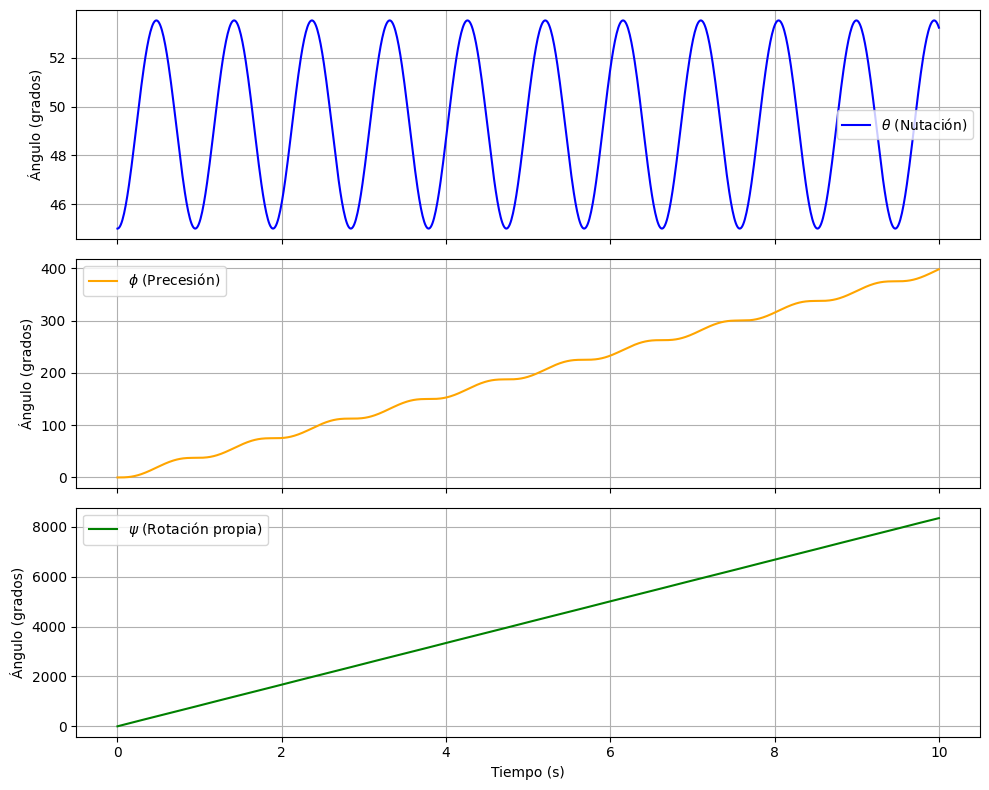

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Nutación (theta)
axs[0].plot(sol.t, np.degrees(sol.y[0]), label=r'$\theta$ (Nutación)', color='blue')
axs[0].set_ylabel('Ángulo (grados)')
axs[0].legend()
axs[0].grid(True)

# Precesión (phi)
axs[1].plot(sol.t, np.degrees(sol.y[1]), label=r'$\phi$ (Precesión)', color='orange')
axs[1].set_ylabel('Ángulo (grados)')
axs[1].legend()
axs[1].grid(True)

# Rotación propia (psi)
axs[2].plot(sol.t, np.degrees(sol.y[2]), label=r'$\psi$ (Rotación propia)', color='green')
axs[2].set_ylabel('Ángulo (grados)')
axs[2].set_xlabel('Tiempo (s)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [13]:
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image, display

# 1. Extraer las soluciones angulares del integrador
theta = sol.y[0]
phi = sol.y[1]

# 2. Aplicar tus reglas de transformación para el Centro de Masa (CM)
x_cm = l * np.sin(theta) * np.sin(phi)
y_cm = -l * np.sin(theta) * np.cos(phi)
z_cm = l * np.cos(theta)

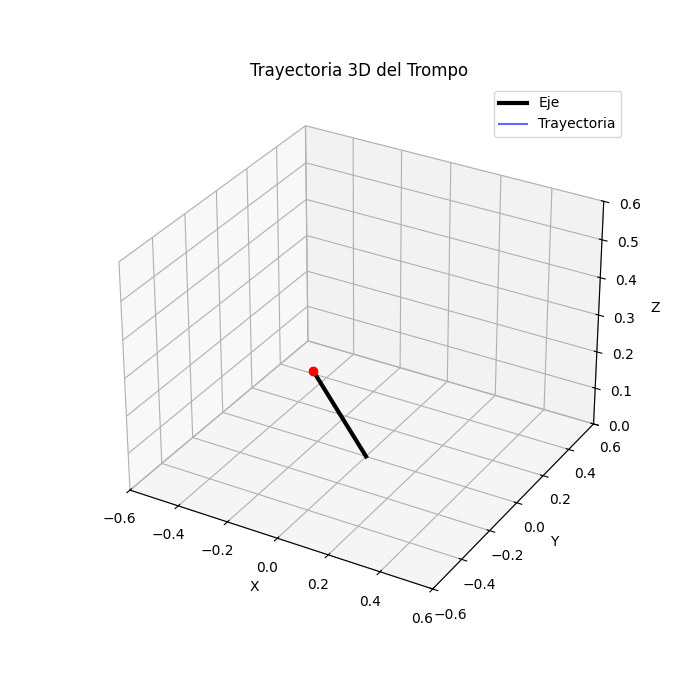

In [19]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([-l*1.2, l*1.2])
ax.set_ylim([-l*1.2, l*1.2])
ax.set_zlim([0, l*1.2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Trayectoria 3D del Trompo')

# Objetos gráficos a actualizar
line_eje, = ax.plot([], [], [], color='black', linewidth=3, label='Eje')
line_trayectoria, = ax.plot([], [], [], color='blue', alpha=0.6, label='Trayectoria')
point_cm, = ax.plot([], [], [], 'ro', markersize=6)
ax.legend()

# 3. Funciones para la animación
def init():
    line_eje.set_data([], [])
    line_eje.set_3d_properties([])
    line_trayectoria.set_data([], [])
    line_trayectoria.set_3d_properties([])
    point_cm.set_data([], [])
    point_cm.set_3d_properties([])
    return line_eje, line_trayectoria, point_cm

def update(num, x, y, z):
    line_eje.set_data([0, x[num]], [0, y[num]])
    line_eje.set_3d_properties([0, z[num]])

    line_trayectoria.set_data(x[:num], y[:num])
    line_trayectoria.set_3d_properties(z[:num])

    point_cm.set_data([x[num]], [y[num]])
    point_cm.set_3d_properties([z[num]])
    return line_eje, line_trayectoria, point_cm

# 4. Crear la animación
# Reducimos los frames o usamos un 'step' si notas que tarda mucho en compilar (ej: frames=len(t_eval)[::2])
ani = FuncAnimation(fig, update, frames=len(t_eval[::2]),
                    fargs=(x_cm, y_cm, z_cm),
                    interval=10, blit=True)

# Cerramos el plot estático inicial para que no se duplique una imagen vacía en Colab
plt.close()

# 5. Guardar la animación como GIF
# Usamos el writer 'pillow' que maneja formatos .gif de manera nativa sin requerir ffmpeg externo
nombre_archivo = 'trompo_animacion.gif'
ani.save(nombre_archivo, writer='pillow', fps=40)

# 6. Mostrar el GIF resultante usando IPython display
display(Image(open(nombre_archivo, 'rb').read()))